# Advanced Plotting of Beam Results

In this notebook we perform linear static analysis of a simply-supported Euler-Bernoulli beam and we plot the results with `Matplotlib`.

## Inputs

In [15]:
a = 1.5 # m
b = 1.5 # m
c = 4.0 # m
d = 1.5 # m
e = 1.5 # m

number_of_modes = 200  # The number of Fourier modes to consider
F = 1.0  # The value of the concentrated load in kN
M = 3.0  # The value of the constant moment in kN.m
q = 0.5  # The value of the uniformly distributed load in kN/m

E = 210000.0  # The modulus of elasticity in kN/m^2
I = 8.333e-4  # The moment of inertia of the beam cross-section in m^4

## Define the Beam and the Loads

In [16]:
from sigmaepsilon.solid.fourier import NavierBeam

beam_length = a + b + c + d + e  # The length of the beam in m
beam = NavierBeam(beam_length, number_of_modes, EI=E * I)

In [17]:
from sigmaepsilon.solid.fourier import LoadGroup, PointLoad, LineLoad

loads = LoadGroup(
    concentrated=LoadGroup(
        LC1=PointLoad(a, [-F, 0.0]),
        LC2=PointLoad(a + b + c + d, [0.0, M]),
    ),
    distributed=LoadGroup(
        LC3=LineLoad([a + b, a + b + c], [-q, 0.0]),
    ),
)

## Calculate Response and Inspect Results

In [18]:
import numpy as np
import time

# the locations of the points where the solution is calculated
# 500 points along the beam length
points = np.linspace(0, beam_length, 500)

start_time = time.time()
solution = beam.linear_static_analysis(points, loads)
end_time = time.time()
print(f"Execution time: {end_time - start_time:.4f} seconds")

Execution time: 0.0080 seconds


Collect all results for all load cases and stack them on top of each other into one Pandas DataFrame.

In [19]:
import pandas as pd

data = []
result_components = None
for addr, _ in loads.values(deep=True, return_address=True):
    print("Processing load case:", addr)
    load_case_solution = solution[addr]
    df = load_case_solution.to_pandas()
    if result_components is None:
        result_components = df.columns.tolist()
    df["load_index"] = list(range(len(df)))
    data.append(df)
print("Result components:", result_components)

# concatenate all load case results
df = pd.concat(data, ignore_index=True)

# aggregate results by load index
df_results = df.groupby("load_index").sum()[result_components]
df_results

Processing load case: ['concentrated', 'LC1']
Processing load case: ['concentrated', 'LC2']
Processing load case: ['distributed', 'LC3']
Result components: ['UY', 'ROTZ', 'CZ', 'EXY', 'MZ', 'SY']


,UY,ROTZ,CZ,EXY,MZ,SY
load_index,,,,,,
0,0.000000e+00,-0.063443,0.000000e+00,0.0,0.000000e+00,-1.843372
1,-1.271398e-03,-0.063441,2.028609e-04,0.0,3.549925e-02,-1.847969
2,-2.542715e-03,-0.063436,3.703951e-04,0.0,6.481655e-02,-1.855388
3,-3.813884e-03,-0.063427,5.164938e-04,0.0,9.038279e-02,-1.855338
4,-5.084846e-03,-0.063415,6.849132e-04,0.0,1.198550e-01,-1.847876
...,...,...,...,...,...,...
495,-3.865275e-03,0.048201,6.868998e-04,0.0,1.202027e-01,1.149879
496,-2.899191e-03,0.048213,5.174448e-04,0.0,9.054921e-02,1.150308
497,-1.932899e-03,0.048222,3.194507e-04,0.0,5.590163e-02,1.150310


## Plot Results

The next block of code created a high quality plot of the structure and the results using `Matplotlib`.

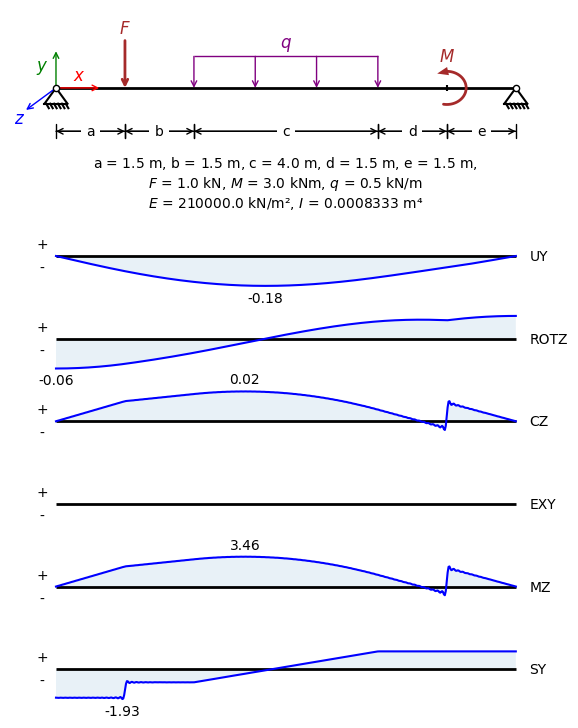

In [20]:
from matplotlib.patches import FancyArrowPatch
from matplotlib import patheffects
import matplotlib.pyplot as plt


def get_max_zorder(ax) -> int:
    """Return the maximum zorder value among all artists in the given Axes."""
    return max([_.zorder for _ in ax.get_children()])


def add_concentrated_bending_moment(
    ax,
    x, y,
    radius=0.45,
    theta1=-90,
    theta2=90,
    direction="cw",
    color="brown",
    linewidth=2.5,
    head_length=10,
    head_width=8,
    n=80,
    head_arc_deg=10.0,      # <- reserve this many degrees for the arrowhead
    label=None,
    label_offset=(0.0, 0.08),
    tick_size=0.15,
    tick_width=1.5,
) -> FancyArrowPatch:
    """Draws a concentrated bending moment symbol on the given Axes."""
    # Convert angles to radians
    t1 = np.deg2rad(theta1)
    t2 = np.deg2rad(theta2)

    # Reserve a small angle for the arrowhead so the tip reaches the arc end visually
    dth = np.deg2rad(head_arc_deg)

    if direction.lower() == "cw":
        # head at theta2, so stop arc early at (theta2 - dth)
        ts_arc = np.linspace(t1, t2 - dth, n)
        th_end = t2
        th_prev = t2 - dth
    elif direction.lower() == "ccw":
        # head at theta1, so start arc late at (theta1 + dth)
        ts_arc = np.linspace(t1 + dth, t2, n)
        th_end = t1
        th_prev = t1 + dth
    else:
        raise ValueError("direction must be 'cw' or 'ccw'")

    # Arc polyline (no head)
    xs = x + radius * np.cos(ts_arc)
    ys = y + radius * np.sin(ts_arc)
    ax.plot(xs, ys, color=color, linewidth=linewidth, solid_capstyle="round", zorder=5)

    # Arrowhead: tangent segment over the reserved angle
    end = np.array([x + radius * np.cos(th_end),  y + radius * np.sin(th_end)])
    prev = np.array([x + radius * np.cos(th_prev), y + radius * np.sin(th_prev)])

    # Arrowhead patch
    head = FancyArrowPatch(
        prev, end,
        arrowstyle=f"-|>,head_length={head_length},head_width={head_width}",
        linewidth=0,
        facecolor=color,
        edgecolor=color,
        shrinkA=0, shrinkB=0,
        zorder=6,
    )
    ax.add_patch(head)
    
    # vertical tick on the beam, at the point of application
    ax.plot(
        [x, x],
        [-tick_size/2, tick_size/2],
        color='black',
        linewidth=tick_width,
        solid_capstyle='butt'
    )

    # label
    if label:
        ax.text(
            x + label_offset[0],
            y + radius + label_offset[1],
            label,
            ha="center",
            va="bottom",
            color=color,
            fontsize=12
        )

    return head


def add_hinge(ax, x, y, s=20, fc='white', ec='k', lw=1, zorder=None, **kwargs):
    if zorder is None:
        zorder = get_max_zorder(ax) + 1
    ax.scatter(x, y, s=s, fc=fc, ec=ec, lw=lw, alpha=1.0, zorder=zorder, **kwargs)


def add_triangle_support(ax, xy, w, h, hinge_params={}):
    x = [xy[0] - w/2, xy[0] + w/2]
    y = [xy[1] - h, xy[1] -h]
    spec = [patheffects.withTickedStroke(angle=-60, spacing=2.5, length=1.5)]
    ax.plot(x, y, color='k', path_effects=spec)
    x = [xy[0] - w/2, xy[0], xy[0] + w/2]
    y = [xy[1] - h, xy[1], xy[1] -h]
    ax.plot(x, y, color='k')
    add_hinge(ax, xy[0], xy[1], **hinge_params)


num_fig = len(result_components) + 1
figzise_y = 3.0 + 1.0 * (num_fig - 1)
fig, axs = plt.subplots(num_fig, 1, figsize=(7.12, figzise_y), height_ratios=[1.5] + [0.5]*(num_fig-1), sharex=True)
beam_length = 10.0

# Draw the beam as a thick line
axs[0].plot([0, beam_length], [0, 0], color='black', linewidth=2, solid_capstyle='butt')

# x axis
axs[0].annotate(
    "",
    xy=(1, 0),
    xytext=(0, 0),
    arrowprops=dict(arrowstyle='->', color='r'),
    fontsize=10
)
axs[0].text(
    0.5,
    0.1,
    r"$x$",
    ha="center",
    va="bottom",
    color="r",
    fontsize=12
)

# y axis
axs[0].annotate(
    "",
    xy=(0, 1),
    xytext=(0, 0),
    arrowprops=dict(arrowstyle='->', color='g'),
    fontsize=10
)
axs[0].text(
    -0.3,
    0.3,
    r"$y$",
    ha="center",
    va="bottom",
    color="g",
    fontsize=12
)

# z axis
axs[0].annotate(
    "",
    xy=(-0.7, -0.6),
    xytext=(0, 0),
    arrowprops=dict(arrowstyle='->', color='b'),
    fontsize=10
)
axs[0].text(
    -0.8,
    -1.0,
    r"$z$",
    ha="center",
    va="bottom",
    color="b",
    fontsize=12
)

# distributed load
distributed_load_height = 0.8
axs[0].plot(
    [a+b, a+b+c], 
    [distributed_load_height, distributed_load_height], 
    color='purple', 
    linewidth=1, 
    solid_capstyle='butt'
)
for i in range(4):
    axs[0].annotate(
        "",
        xy=(a+b + i*c/3, distributed_load_height),
        xytext=(a+b + i*c/3, 0),
        arrowprops=dict(arrowstyle='<-', color='purple', shrinkA=0, shrinkB=0),
        fontsize=10,
    )
axs[0].text(
    a+b+c/2,
    distributed_load_height + 0.08,
    r"$q$",
    ha="center",
    va="bottom",
    color="purple",
    fontsize=12
)

# concentrated load
concentrated_load_height = 1.2
axs[0].annotate(
    "",
    xy=(a, concentrated_load_height),
    xytext=(a, 0),
    arrowprops=dict(arrowstyle='<-', color='brown', linewidth=2, shrinkA=0, shrinkB=0),
    fontsize=10,
)
axs[0].text(
    a,
    concentrated_load_height + 0.1,
    r"$F$",
    ha="center",
    va="bottom",
    color="brown",
    fontsize=12
)

# concentrated bending moment
moment_tick_size = 0.15
add_concentrated_bending_moment(
    axs[0],
    x=a+b+c+d, y=0.0,           # slightly above beam
    radius=0.42,
    theta1=-100, theta2=120,  # near-semicircle
    direction="cw",         # makes the head appear on the left like your screenshot
    color="brown",
    linewidth=2.0,
    head_length=8,
    head_width=3,
    head_arc_deg=30,
    label=r"$M$",
    label_offset=(0.0, 0.15),
    tick_size=moment_tick_size
)

# left support
add_triangle_support(axs[0], (0, 0), 0.5, 0.4)

# right support
add_triangle_support(axs[0], (beam_length, 0), 0.5, 0.4)

# dimension lines
dimension_line_y = -1.1
dimension_segments = [
    (0, a, "a"),
    (a, a+b, "b"),
    (a+b, a+b+c, "c"),
    (a+b+c, a+b+c+d, "d"),
    (a+b+c+d, a+b+c+d+e, "e"),
]
arrows = '<->', '|-|'
for segment in dimension_segments:
    for arr in arrows:
        arrowprops=dict(arrowstyle=arr, shrinkA=0, shrinkB=0)
        if arr == '|-|':
            arrowprops["mutation_scale"] = 5
        axs[0].annotate(
            "", 
            xy=(segment[0], dimension_line_y), 
            xytext=(segment[1], dimension_line_y), 
            arrowprops=arrowprops
        )
    bbox=dict(fc="white", ec="none")
    axs[0].text((segment[0] + segment[1]) / 2, dimension_line_y, segment[2], color="black", \
        ha="center", va="center", bbox=bbox, fontsize=10)

# formatting of the first plot
axs[0].set_xlim(-1, beam_length + 1)
axs[0].set_ylim(-3, 2)
axs[0].axis('off')

# beam parameters text
params_text = f"a = ${a}$ m, b = ${b}$ m, c = ${c}$ m, d = ${d}$ m, e = ${e}$ m, \n" + \
              f"$F$ = ${F}$ kN, $M$ = ${M}$ kNm, $q$ = ${q}$ kN/m \n" + \
              f"$E$ = ${E}$ kN/m², $I$ = ${I}$ m⁴"
axs[0].text((-1 + beam_length + 1) / 2, dimension_line_y - 1.3, params_text, color="black", \
        ha="center", va="center",  fontsize=10)

# plot the results
for i, comp in enumerate(result_components):
    # get the component results
    comp_results = df_results[comp]
    
    # draw the beam as a thick line
    axs[i + 1].plot([0, beam_length], [0, 0], color='black', linewidth=2, solid_capstyle='butt')
    
    # plot the normalized result
    comp_y = comp_results / comp_results.abs().max()
    axs[i + 1].plot(points, comp_y, color='blue', linewidth=1.5, label=f'Normalized {comp}')
    axs[i + 1].fill_between(points, comp_y, alpha=0.1)
    
    # component label on the right side
    axs[i + 1].text(beam_length + 0.3, 0, comp, fontsize=10, va='center', ha='left', color='black')
    
    # plus and minus signs on the left side
    axs[i + 1].text(-0.3, 0.4, "+", fontsize=10, va='center', ha='center', color='black')
    axs[i + 1].text(-0.3, -0.4, "-", fontsize=10, va='center', ha='center', color='black')
    
    # label the maximum absolute value point
    if comp_results.abs().max() > 0:
        arg_abs_max = np.argmax(comp_results.abs())
        sign = np.sign(comp_results.iloc[arg_abs_max])
        comp_label_offset = 0.4 * sign
        axs[i + 1].text(
            points[arg_abs_max], 
            comp_results.iloc[arg_abs_max] / comp_results.abs().max() + comp_label_offset, 
            f"{comp_results.iloc[arg_abs_max]:.2f}",
            fontsize=10, 
            va='center', 
            ha='center', 
            color='black'
        )
        
    # formatting
    axs[i + 1].set_xlim(-1, beam_length + 1)
    axs[i + 1].set_ylim(-1.1, 1.1)
    axs[i + 1].axis('off')

plt.show()